In [1]:
# 변수의 shape, type, value 확인
def p(var,_str='') :
    if _str=='\n' or _str=='cr' :
        _str = '\n'
    else :
        print(f'[{_str}]:')
        _str = ''
    if type(var)!=type([]):
        try:
            print(f'Shape:{var.shape}')
        except :
            pass
    print(f'Type: {type(var)}')
    print(f'Values: {var}'+_str)

def pst(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}, {type(_x)}')
def ps(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}')

## **Import Module**

In [2]:
%%capture
!pip -q install torchinfo

# **실습 : DCGAN with MNIST**

## **Import Module**

In [3]:
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader, random_split, ConcatDataset
from torchvision.transforms import v2

#from torchmetrics import functional as FM
from torchinfo import summary
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "8"

torch.__version__
device='cuda:0'

In [ ]:
# (Google Drive 연결 셀 제거 — 저장 경로는 /content/models/PT/ 로 바꿨다)
# # gdriver mount to load saved model


## **DataSet**

### Load

In [5]:
from torchvision.datasets import FashionMNIST, MNIST

class Normalize:
    def __call__(self, sample):
        sample = np.array(sample)
        image = (sample - 127.5) / 127.5
        return torch.FloatTensor(image).unsqueeze(dim=0)

# Normalize data to [-1 ~ 1]
transform = v2.Compose([Normalize(),])

# download path 정의
download_root = './MNIST_DATASET'
train_dataset = MNIST(download_root, transform=transform, train=True, download=True)
test_dataset = MNIST(download_root, transform=transform, train=False, download=True)

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9912422/9912422 [00:10<00:00, 903692.11it/s] 


Extracting ./MNIST_DATASET/MNIST/raw/train-images-idx3-ubyte.gz to ./MNIST_DATASET/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28881/28881 [00:00<00:00, 65189.49it/s]


Extracting ./MNIST_DATASET/MNIST/raw/train-labels-idx1-ubyte.gz to ./MNIST_DATASET/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 1648877/1648877 [00:06<00:00, 238888.59it/s]


Extracting ./MNIST_DATASET/MNIST/raw/t10k-images-idx3-ubyte.gz to ./MNIST_DATASET/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4542/4542 [00:00<00:00, 12845939.83it/s]

Extracting ./MNIST_DATASET/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./MNIST_DATASET/MNIST/raw



### Preprocessing

## **Model**

### Function define for saving model

In [6]:
save_path='/content/models/PT/'
os.makedirs(save_path, exist_ok=True)

In [7]:
def save_models(title, epoch):
    torch.save(generator, save_path+"dcgan_generator_{}_{}.pt".format(title, epoch))
    torch.save(discriminator, save_path+"dcgan_discriminator_{}_{}.pt".format(title, epoch))

def load_models(title, epoch):
    gen = torch.load(save_path+"dcgan_generator_{}_{}.pt".format(title, epoch))
    dis = torch.load(save_path+"dcgan_discriminator_{}_{}.pt".format(title, epoch))
    return gen, dis

In [8]:
train_model = True      # T: training
#train_model = False     # F: loading

### model params

In [9]:
latent_dim = 100
height = 28
width = 28
channels = 1

### Define generator

In [10]:
# Generator model
class Generator(nn.Module):
    def __init__(self, latent_dim, channels):
        super(Generator, self).__init__()
        self.generator = nn.Sequential(
            nn.Linear(latent_dim, 128 * 7 * 7),
            nn.Unflatten(1, (128, 7, 7)),
            nn.BatchNorm2d(128,momentum=0.8),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(128, 128, 5, 2,
                               padding=2, output_padding=1),
            nn.BatchNorm2d(128,momentum=0.8),  #(128,14,14)
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(128, 64, 5, 2,
                               padding=2, output_padding=1),
            nn.BatchNorm2d(64,momentum=0.8),   #(64,28,28)
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(64, 32, 5, 1, padding=2),
            nn.BatchNorm2d(32,momentum=0.8),   #(32,28,28)
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, channels, 5, padding=2),
            nn.Tanh()             #(1,28,28)
        )

    def forward(self, x):
        out = self.generator(x)
        return out

generator = Generator(latent_dim, channels).to(device)
summary(generator, input_size=(8, 100))

Layer (type:depth-idx)                   Output Shape              Param #
Generator                                [8, 1, 28, 28]            --
├─Sequential: 1-1                        [8, 1, 28, 28]            --
│    └─Linear: 2-1                       [8, 6272]                 633,472
│    └─Unflatten: 2-2                    [8, 128, 7, 7]            --
│    └─BatchNorm2d: 2-3                  [8, 128, 7, 7]            256
│    └─LeakyReLU: 2-4                    [8, 128, 7, 7]            --
│    └─ConvTranspose2d: 2-5              [8, 128, 14, 14]          409,728
│    └─BatchNorm2d: 2-6                  [8, 128, 14, 14]          256
│    └─LeakyReLU: 2-7                    [8, 128, 14, 14]          --
│    └─ConvTranspose2d: 2-8              [8, 64, 28, 28]           204,864
│    └─BatchNorm2d: 2-9                  [8, 64, 28, 28]           128
│    └─LeakyReLU: 2-10                   [8, 64, 28, 28]           --
│    └─ConvTranspose2d: 2-11             [8, 32, 28, 28]           

### Define discriminator

In [11]:
# Discriminator model
class Discriminator(nn.Module):
    def __init__(self, channels):
        super(Discriminator, self).__init__()
        self.discriminator = nn.Sequential(
#            nn.LeakyReLU(0.2),
            nn.Conv2d(channels, 32, 5, 2, padding=2),
            nn.LeakyReLU(0.2),
#            nn.Dropout(0.25),
            nn.Conv2d(32, 64, 5, 2, padding=2),
            nn.LeakyReLU(0.2),
#            nn.Dropout(0.25),
            nn.Conv2d(64, 128, 5, 2, padding=2),
            nn.LeakyReLU(0.2),
#            nn.Dropout(0.25),
            nn.Conv2d(128, 256, 5, 1, padding=2),
            nn.Flatten(),
            nn.Linear(256*4*4, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        out = self.discriminator(x)
        return out

discriminator = Discriminator(channels).to(device)
summary(discriminator, input_size=(8, channels, height, width))

Layer (type:depth-idx)                   Output Shape              Param #
Discriminator                            [8, 1]                    --
├─Sequential: 1-1                        [8, 1]                    --
│    └─Conv2d: 2-1                       [8, 32, 14, 14]           832
│    └─LeakyReLU: 2-2                    [8, 32, 14, 14]           --
│    └─Conv2d: 2-3                       [8, 64, 7, 7]             51,264
│    └─LeakyReLU: 2-4                    [8, 64, 7, 7]             --
│    └─Conv2d: 2-5                       [8, 128, 4, 4]            204,928
│    └─LeakyReLU: 2-6                    [8, 128, 4, 4]            --
│    └─Conv2d: 2-7                       [8, 256, 4, 4]            819,456
│    └─Flatten: 2-8                      [8, 4096]                 --
│    └─Linear: 2-9                       [8, 1]                    4,097
│    └─Sigmoid: 2-10                     [8, 1]                    --
Total params: 1,080,577
Trainable params: 1,080,577
Non-trainable p

In [12]:
#torch.onnx.export(discriminator, torch.zeros((8, channels, height, width)).to(device), '4.4_dcgan_discriminator.onnx')

### Fit function

In [13]:
batch_size = 600
num_epochs = 10
print_step=100
lr = 0.0001

In [14]:
generator = Generator(latent_dim, channels).to(device)
discriminator = Discriminator(channels).to(device)
optimizer_d = torch.optim.Adam(discriminator.parameters(), lr=lr)
optimizer_g = torch.optim.Adam(generator.parameters(), lr=lr)

In [15]:
def show_images(generated_images, n=4, m=8, figsize=(8, 4)):
    fig = plt.figure(figsize=figsize)
    plt.subplots_adjust(top=1, bottom=0, hspace=0, wspace=0.05)
    for i in range(n):
        for j in range(m):
            k = i * m + j
            ax = fig.add_subplot(n, m, i * m + j + 1)
            ax.imshow(generated_images[k][0, :, :])#, cmap=plt.cm.bone)
            ax.grid(False)
            ax.xaxis.set_ticks([])
            ax.yaxis.set_ticks([])
    plt.tight_layout()
    plt.show()

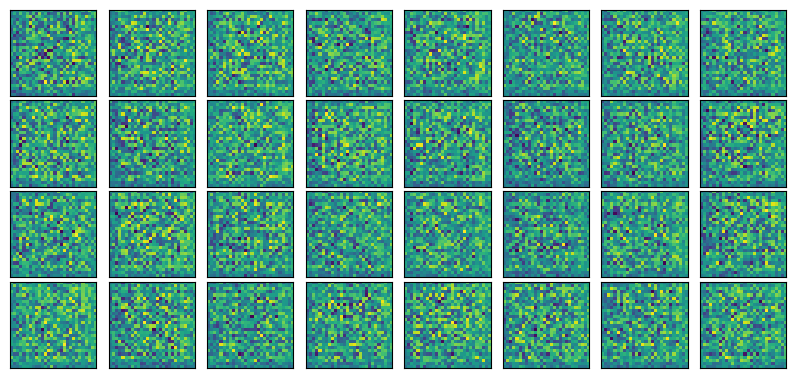

In [16]:
noise_data = torch.randn((batch_size, latent_dim))
show_images(0.5 * generator(noise_data.to(device)).cpu().detach().numpy() + 0.5) #Generator Af='tanh'

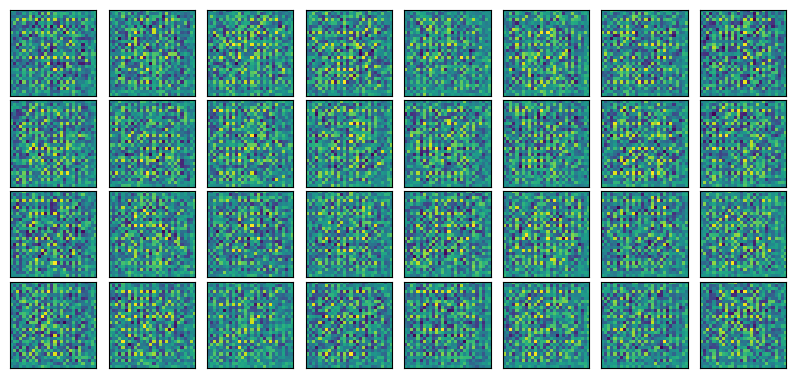

In [17]:
def train(num_epochs, print_every):
    for epoch in range(num_epochs):
        idx = np.random.randint(0, len(train_dataset), batch_size)
        r_samples = torch.cat([train_dataset[i][0].unsqueeze(dim=0) for i in idx])
        # Data for training the discriminator
        r_labels = torch.ones((batch_size, 1))
        latent_samples = torch.randn((batch_size, latent_dim))
        f_samples = generator(latent_samples.to(device))
        f_labels = torch.zeros((batch_size, 1))
        all_samples = torch.cat((r_samples.to(device), f_samples))
        all_labels = torch.cat((r_labels, f_labels))
        # Training the discriminator
        discriminator.zero_grad()
        output_d = discriminator(all_samples.to(device))
        loss_d = F.binary_cross_entropy(output_d, all_labels.to(device))
        loss_d.backward()
        optimizer_d.step()

        # Data for training the generator
        latent_samples = torch.randn((batch_size, latent_dim))
        # Training the generator
        generator.zero_grad()
        f_samples = generator(latent_samples.to(device))
        output_d = discriminator(f_samples.to(device))
        loss_g = F.binary_cross_entropy(output_d, r_labels.to(device))
        loss_g.backward()
        optimizer_g.step()

        # Show loss
        if epoch % print_every == 0:
            print(f"Epoch: {epoch} Loss D.: {loss_d}")
            print(f"Epoch: {epoch} Loss G.: {loss_g}")

### Fit 500

In [18]:
%%time
if train_model == True:
    history500 = train(500, 10)
    save_models("mnist", 500)
else:
    generator, _, _ = load_models("mnist",500)

Epoch: 0 Loss D.: 0.6924074292182922
Epoch: 0 Loss G.: 0.701216995716095
Epoch: 10 Loss D.: 0.5639854073524475
Epoch: 10 Loss G.: 0.6508007645606995
Epoch: 20 Loss D.: 0.3295295834541321
Epoch: 20 Loss G.: 1.0963621139526367
Epoch: 30 Loss D.: 0.06887445598840714
Epoch: 30 Loss G.: 3.3864858150482178
Epoch: 40 Loss D.: 0.15754804015159607
Epoch: 40 Loss G.: 4.62863302230835
Epoch: 50 Loss D.: 1.4940165281295776
Epoch: 50 Loss G.: 1.4798450469970703
Epoch: 60 Loss D.: 0.22895395755767822
Epoch: 60 Loss G.: 1.43996262550354
Epoch: 70 Loss D.: 0.05374913662672043
Epoch: 70 Loss G.: 4.354686737060547
Epoch: 80 Loss D.: 0.04787634685635567
Epoch: 80 Loss G.: 4.488379001617432
Epoch: 90 Loss D.: 0.13358044624328613
Epoch: 90 Loss G.: 2.104527473449707
Epoch: 100 Loss D.: 0.031055772677063942
Epoch: 100 Loss G.: 4.511471748352051
Epoch: 110 Loss D.: 0.012098724022507668
Epoch: 110 Loss G.: 4.771905422210693
Epoch: 120 Loss D.: 0.013090047985315323
Epoch: 120 Loss G.: 4.188109874725342
Epoch: 

Wall time: 1min 7s


>#### Plot 500

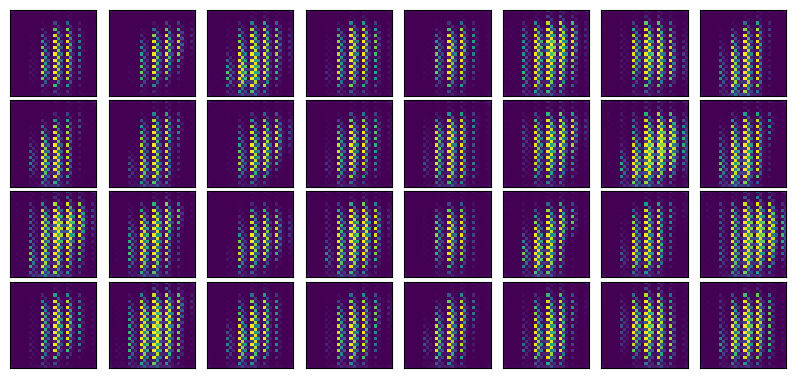

In [19]:
noise_data = torch.randn((batch_size, latent_dim))
show_images(0.5 * generator(noise_data.to(device)).cpu().detach().numpy() + 0.5) #Generator Af='tanh'

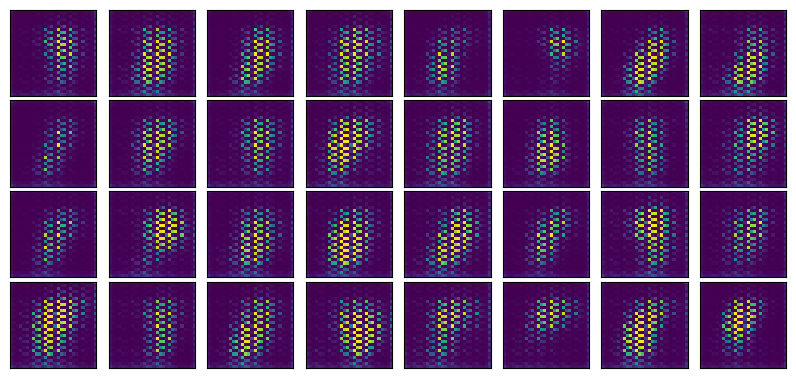

### Fit   +4500

In [20]:
train_model = True

In [21]:
%%time
if train_model == True:
    history500 = train(4500, 100)
    save_models("mnist", 5000)
else:
    generator, _, _ = load_models("mnist", 5000)

Epoch: 0 Loss D.: 0.3122309446334839
Epoch: 0 Loss G.: 2.058457374572754
Epoch: 100 Loss D.: 0.011695176362991333
Epoch: 100 Loss G.: 5.050522804260254
Epoch: 200 Loss D.: 0.17291267216205597
Epoch: 200 Loss G.: 4.216598987579346
Epoch: 300 Loss D.: 0.009182815439999104
Epoch: 300 Loss G.: 5.449793338775635
Epoch: 400 Loss D.: 0.0024829567410051823
Epoch: 400 Loss G.: 6.460553169250488
Epoch: 500 Loss D.: 0.0008343486115336418
Epoch: 500 Loss G.: 6.861082553863525
Epoch: 600 Loss D.: 0.0005848726723343134
Epoch: 600 Loss G.: 7.215983867645264
Epoch: 700 Loss D.: 0.0009299111552536488
Epoch: 700 Loss G.: 7.4011712074279785
Epoch: 800 Loss D.: 0.0024234438315033913
Epoch: 800 Loss G.: 6.5545549392700195
Epoch: 900 Loss D.: 0.2872104048728943
Epoch: 900 Loss G.: 2.8759078979492188
Epoch: 1000 Loss D.: 0.2752792537212372
Epoch: 1000 Loss G.: 2.987164258956909
Epoch: 1100 Loss D.: 0.46259966492652893
Epoch: 1100 Loss G.: 1.733864188194275
Epoch: 1200 Loss D.: 0.5270152688026428
Epoch: 1200 

Wall time: 27min 14s


>#### Plot 5000

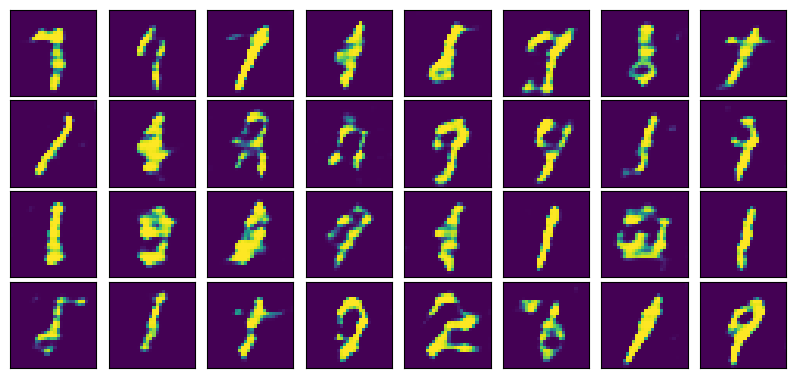

In [22]:
noise_data = torch.randn((batch_size, latent_dim))
show_images(0.5 * generator(noise_data.to(device)).cpu().detach().numpy() + 0.5) #Generator Af='tanh'

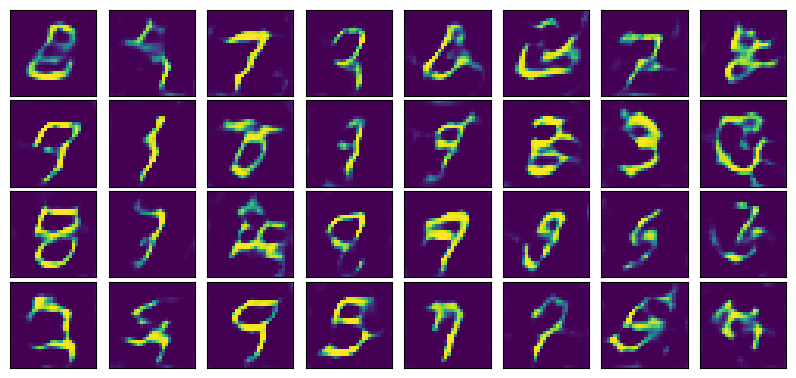

### Fit +15000

In [23]:
%%time
if train_model == True:
    train(15000, 100)
    save_models("mnist", 20000)
else:
    generator, _, _ = load_models("mnist", 20000)

Epoch: 0 Loss D.: 0.22526311874389648
Epoch: 0 Loss G.: 3.521256923675537
Epoch: 100 Loss D.: 0.18681882321834564
Epoch: 100 Loss G.: 3.6806528568267822
Epoch: 200 Loss D.: 0.20230506360530853
Epoch: 200 Loss G.: 3.3856780529022217
Epoch: 300 Loss D.: 0.16395072638988495
Epoch: 300 Loss G.: 3.1289587020874023
Epoch: 400 Loss D.: 0.11884602904319763
Epoch: 400 Loss G.: 3.982632637023926
Epoch: 500 Loss D.: 0.19944092631340027
Epoch: 500 Loss G.: 3.651556968688965
Epoch: 600 Loss D.: 0.17011620104312897
Epoch: 600 Loss G.: 3.778813600540161
Epoch: 700 Loss D.: 0.24984624981880188
Epoch: 700 Loss G.: 3.853963613510132
Epoch: 800 Loss D.: 0.19003695249557495
Epoch: 800 Loss G.: 3.3971872329711914
Epoch: 900 Loss D.: 0.23410116136074066
Epoch: 900 Loss G.: 3.252957582473755
Epoch: 1000 Loss D.: 0.2136363834142685
Epoch: 1000 Loss G.: 3.014854907989502
Epoch: 1100 Loss D.: 0.23475901782512665
Epoch: 1100 Loss G.: 3.0578365325927734
Epoch: 1200 Loss D.: 0.16428162157535553
Epoch: 1200 Loss G.

Wall time: 1h 31min 19s

>#### Plot 20000

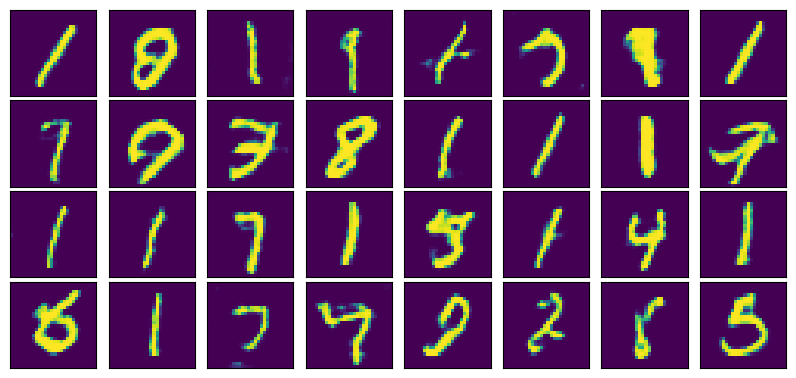

In [24]:
noise_data = torch.randn((batch_size, latent_dim))
show_images(0.5 * generator(noise_data.to(device)).cpu().detach().numpy() + 0.5) #Generator Af='tanh'

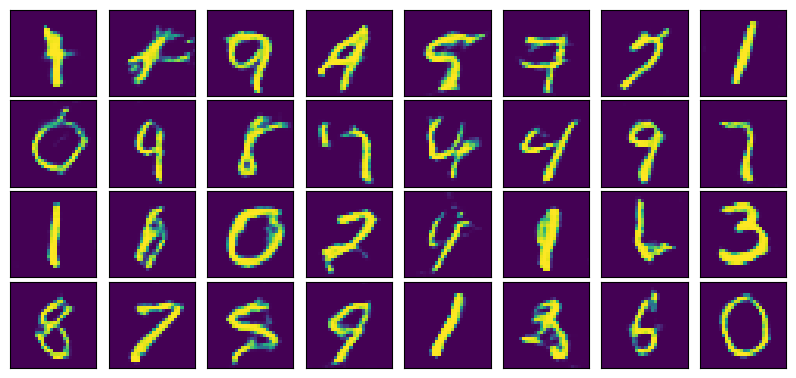

## **DCGAN Model load**

## Load model

### load dc gan mnist and show the result

In [25]:
latent_dim = 100

In [26]:
def show_images(generated_images, n=4, m=8, figsize=(9, 5)):
    fig = plt.figure(figsize=figsize)
    plt.subplots_adjust(top=1, bottom=0, hspace=0, wspace=0.05)
    for i in range(n):
        for j in range(m):
            k = i * m + j
            ax = fig.add_subplot(n, m, i * m + j + 1)
            ax.imshow(generated_images[k][0, :, :])#, cmap=plt.cm.bone)
            ax.grid(False)
            ax.xaxis.set_ticks([])
            ax.yaxis.set_ticks([])
    plt.tight_layout()
    plt.show()

In [27]:
generator = torch.load(save_path+"dcgan_generator_mnist_20000.pt")

<ipython-input-27-da2ec0b8d2cf>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  generator = torch.load(save_path+"dcgan_generator_mnist_20000.pt")


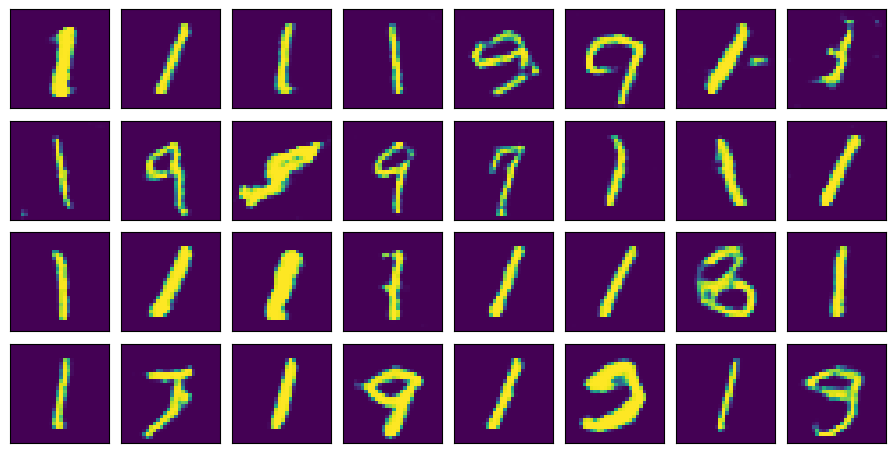

In [28]:
noise_data = torch.randn((batch_size, latent_dim))
show_images(0.5 * generator(noise_data.to(device)).cpu().detach().numpy() + 0.5)

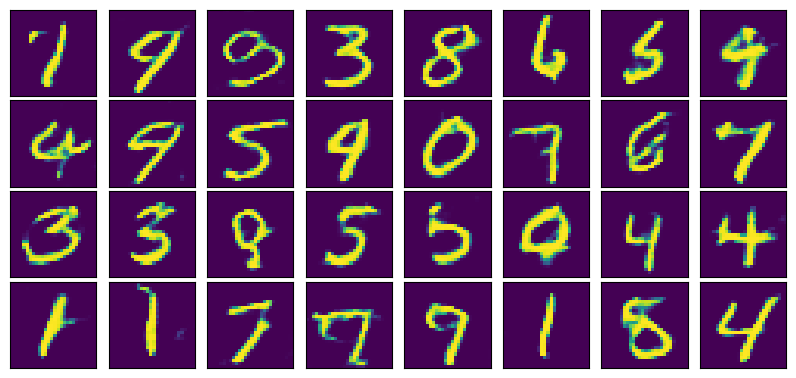